In [32]:
%reload_ext autoreload
%autoreload 2
import os
from pathlib import Path
import sys
from typing import Any, Literal, Optional

from frozendict import frozendict
from qecbench import TaskStats

# Add parent directory to the path
sys.path.insert(0, os.path.abspath('..'))

# Register learned decoders so they can be instantiated by `qecdec.decoders.create_decoder`.
import learned_decoders  # noqa: F401
from utils import get_csv_path

In [4]:
import matplotlib.pyplot as plt

import plot_utils

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

# Helper functions

In [10]:
def load_stats(
    *,
    circuit_name: str,
    circuit_params: dict[str, Any],
    error_rates: list[float],
    decoders: list[tuple[str, dict[str, Any]]],
) -> list[TaskStats]:
    filtered_stats: list[TaskStats] = []
    for decoder_name, decoder_params in decoders:
        csv_path = get_csv_path(circuit_name, circuit_params, decoder_name)
        all_stats = TaskStats.load_csv(csv_path)
        for s in all_stats:
            m = s.metadata
            if m.error_rate not in error_rates:
                continue
            if m.decoder_params != frozendict(decoder_params):
                continue
            filtered_stats.append(s)
    return filtered_stats


In [22]:
def plot_fr_vs_iter_budget(
    stats: list[TaskStats],
    *,
    x_metric: Literal["iter_budget", "avg_iter"],
    y_metric: Literal["fr_per_shot", "fr_per_round"],
    suptitle: Optional[str] = None,
    save_at: Optional[str | Path] = None,
):
    def label_fn(s: TaskStats) -> str:
        lb = s.metadata.decoder_name
        if lb in ["MultiRelayBP", "LearnedMultiRelayBP"]:
            lb += f"(N={s.metadata.decoder_params['num_chains']})"
        return lb

    fig, ax = plt.subplots()
    plot_utils.plot_fr_vs_iter_budget(
        stats,
        ax,
        budget_step=50,
        x_metric=x_metric,
        y_metric=y_metric,
        label_fn=label_fn,
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    fig.tight_layout()
    if save_at:
        fig.savefig(save_at)
    plt.show()

# BB_144_12_12_Circuit, basis=Z, rounds=12, error_rate=0.001

Loaded 3 benchmark entries


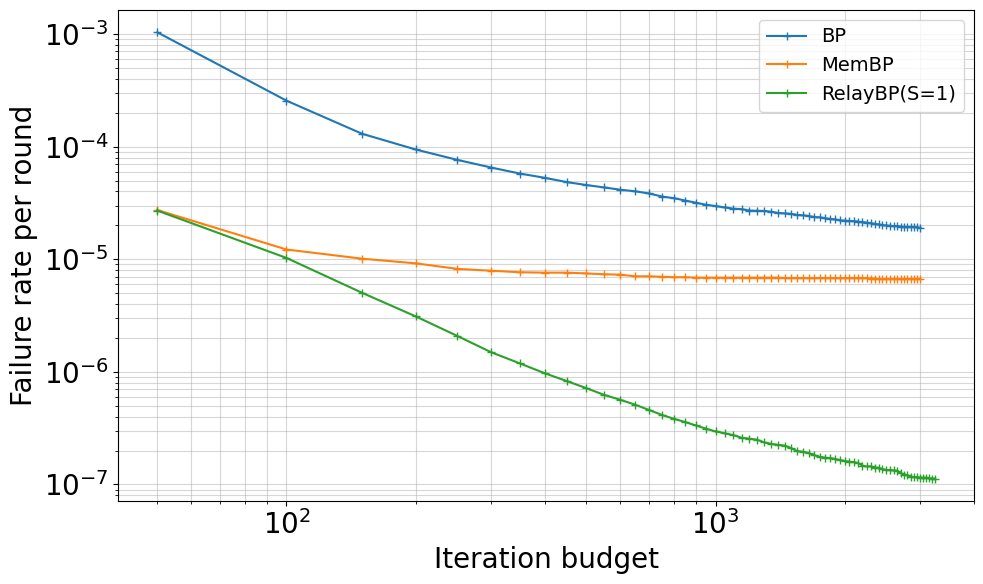

In [20]:
circuit_name = "BB_144_12_12_Circuit"
circuit_params = {"basis": "Z", "rounds": 12}
error_rate = 0.001

bp_params = {"max_iter": 3000}
membp_params = {"max_iter": 3000, "gamma": 0.2}
relaybp_params = {
    "gamma0": 0.2,
    "gamma_dist_interval": (-0.19806670996164882, 0.6200937872049607),
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}
loaded_stats = load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    error_rates=[error_rate],
    decoders=[
        ("BP", bp_params),
        ("MemBP", membp_params),
        ("RelayBP", relaybp_params),
    ],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(loaded_stats, x_metric="iter_budget", y_metric="fr_per_round")


# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11, error_rate=0.001

Loaded 6 benchmark entries


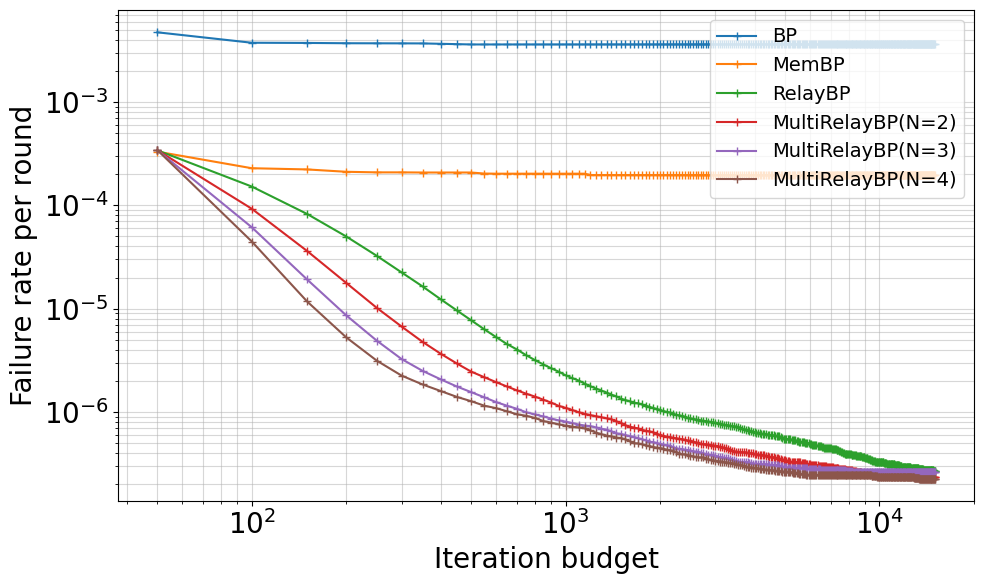

In [28]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rate = 0.001

bp_params = {"max_iter": 15000}
membp_params = {"max_iter": 15000, "gamma": 0.55}
relaybp_params = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "num_relays": 300,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}
loaded_stats = load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    error_rates=[error_rate],
    decoders=[
        ("BP", bp_params),
        ("MemBP", membp_params),
        ("RelayBP", relaybp_params),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 2}),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 3}),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 4}),
    ],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

# plot_fr_vs_iter_budget(loaded_stats, x_metric="avg_iter", y_metric="fr_per_round")
plot_fr_vs_iter_budget(loaded_stats, x_metric="iter_budget", y_metric="fr_per_round")


# RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11, error_rate=0.001

Loaded 10 benchmark entries


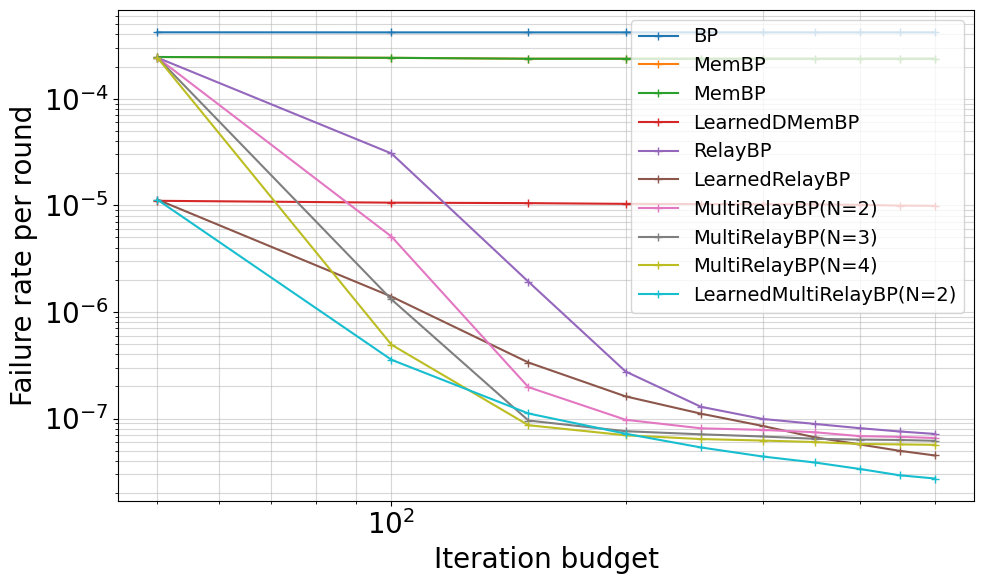

In [37]:
circuit_name = "RotatedSurfaceCode_Phenom"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rate = 0.001

bp_params = {"max_iter": 500}
membp_params = {"max_iter": 500, "gamma": 0.65}
learned_dmembp_params = {
    "max_iter": 500,
    "ckpt_rel_path": "torchdecoder/runs/RotatedSurfaceCode_Phenom/basis=Z_d=11_rounds=11/LearnedDMemBP/run_0/checkpoints/best_model.ckpt",
}
relaybp_params = {
    "gamma0": 0.65,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "num_relays": 9,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}
learned_relaybp_params = {
    "ckpt_rel_path": "torchdecoder/runs/RotatedSurfaceCode_Phenom/basis=Z_d=11_rounds=11/LearnedDMemBP/run_0/checkpoints/best_model.ckpt",
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "num_relays": 9,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}
loaded_stats = load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    error_rates=[error_rate],
    decoders=[
        ("BP", bp_params),
        ("MemBP", membp_params),
        ("MemBP", membp_params),
        ("LearnedDMemBP", learned_dmembp_params),
        ("RelayBP", relaybp_params),
        ("LearnedRelayBP", learned_relaybp_params),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 2}),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 3}),
        ("MultiRelayBP", {**relaybp_params, "num_chains": 4}),
        ("LearnedMultiRelayBP", {**learned_relaybp_params, "num_chains": 2}),
        # ("LearnedMultiRelayBP", {**learned_relaybp_params, "num_chains": 3}),
        # ("LearnedMultiRelayBP", {**learned_relaybp_params, "num_chains": 4}),
    ],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(loaded_stats, x_metric="iter_budget", y_metric="fr_per_round")


# 5. Hexagonal color code d=11, phenomenological noise, basis=Z, p=0.005

Loaded 3 benchmark entries


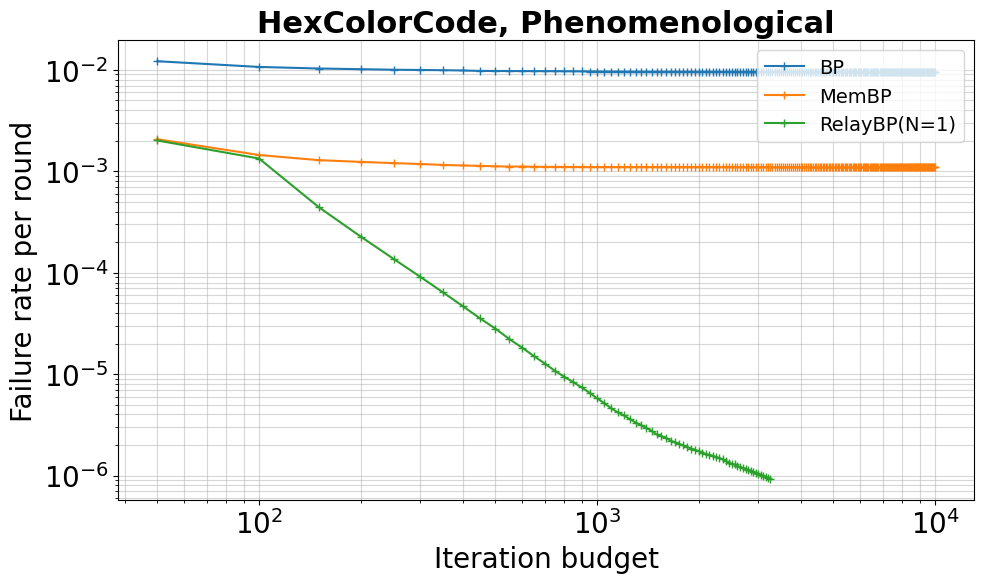

In [8]:
qec_params = QECParams(
    code="HexColorCode",
    noise_model="Phenomenological",
    d=11,
    rounds=11,
    basis="Z",
)
physical_error_rate = 0.005
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.55}
relaybp_kwargs = {
    "gamma0": 0.55,
    "gamma_dist_interval": [-0.21295457674166532, 0.697918233656232],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
loaded_stats = load_stats(
    qec_params=qec_params,
    decoder_name_to_kwargs={
        "BP": [bp_kwargs],
        "MemBP": [membp_kwargs],
        "RelayBP": [relaybp_kwargs],
    },
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

plot_fr_vs_iter_budget(
    loaded_stats, qec_params=qec_params, x_metric="iter_budget", y_metric="fr_per_round"
)
